# DATA CHALLENGE

# 1. Load and Convert Data 
### Test avec Contrast Limited Adaptive Histogram Equalization (CLAHE)

In [1]:
import numpy as np
import glob
import cv2
import matplotlib.pyplot as plt
from skimage import io, color, morphology, filters
from skimage.morphology import diamond,disk,square, remove_small_objects, remove_small_holes,opening,closing,dilation,erosion

[[33278 33305 33270 ... 33269 33273 33349]
 [33310 33237 33305 ... 33305 33312 33297]
 [33352 33255 33280 ... 33305 33316 33255]
 ...
 [33342 33279 33307 ... 33271 33294 33269]
 [33278 33290 33300 ... 33304 33304 33268]
 [33297 33275 33326 ... 33249 33305 33271]]


/var/folders/ty/mz254c797ml4f8jydylf3h6c0000gn/T/ipykernel_31253/2773778599.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(image, cmap='grey')
/opt/anaconda3/envs/phelma/lib/python3.10/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


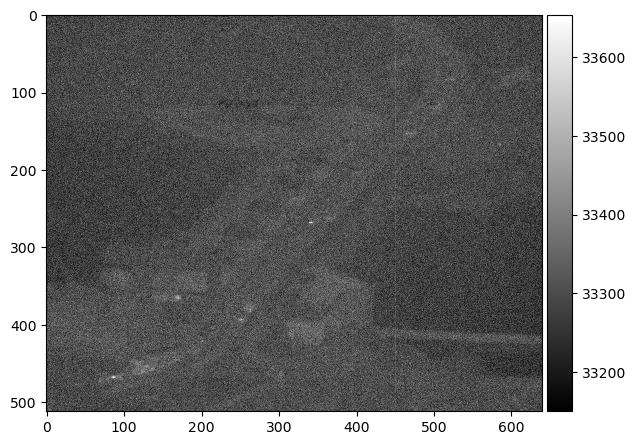

In [2]:
image=io.imread('images/frame_0000ld1.png')
io.imshow(image, cmap='grey')
print(image)

#### Normalisation min-max simple : image_8bit = (image_16bit - min) / (max - min) * 255

/var/folders/ty/mz254c797ml4f8jydylf3h6c0000gn/T/ipykernel_31253/2076493587.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_final_simple)


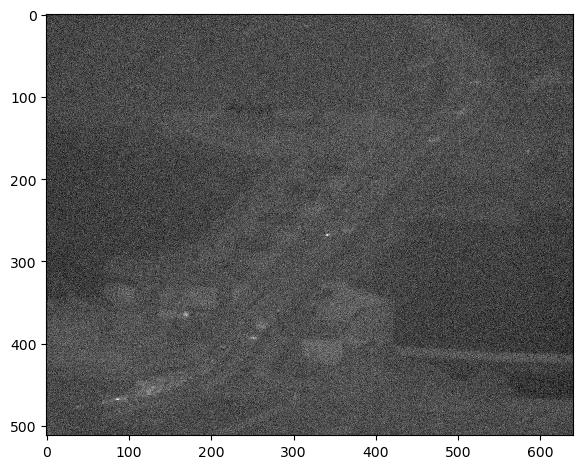

In [3]:
img_final_simple = (image - np.min(image)) / (np.max(image) - np.min(image)) * 255
img_final_simple = img_final_simple.astype(np.uint8)
io.imshow(img_final_simple)

#### en utilisant CLAHE (=Contrast Limited Adaptive Histogram Equalization)

/var/folders/ty/mz254c797ml4f8jydylf3h6c0000gn/T/ipykernel_31253/881963002.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_final)


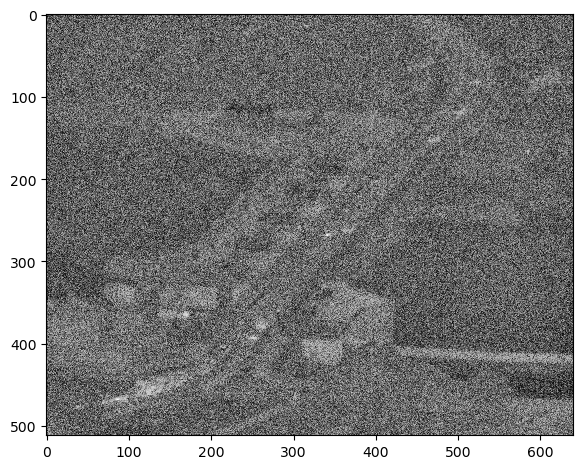

In [4]:
import cv2
import numpy as np

# Conversion nécessaire pour CLAHE (qui travaille en 8 bits)
img_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_final = clahe.apply(img_8bit)
io.imshow(img_final)

#### en utilisant des percentile 

In [5]:
def convert_to_8_img(img_16bit):
    """""
    Convert 16 bits img into 8 bits using percentiles to not be biased by outliers  
    arg : img 
    return : converted img in 8 bits
    """""
    # 1. Utiliser des percentiles pour ignorer les pixels aberrants (très chauds ou très froids)
    # Cela permet de mieux voir les détails de la scène sans être ébloui par les extrêmes
    p2, p98 = np.percentile(img_16bit, (2, 98))
    img_clipped = np.clip(img_16bit, p2, p98)
    
    # 2. Normaliser entre 0 et 255
    img_8bit = ((img_clipped - p2) / (p98 - p2) * 255).astype(np.uint8)
    return img_8bit

img_percentile = convert_to_8_img(image)


#### Compare 2 methods 

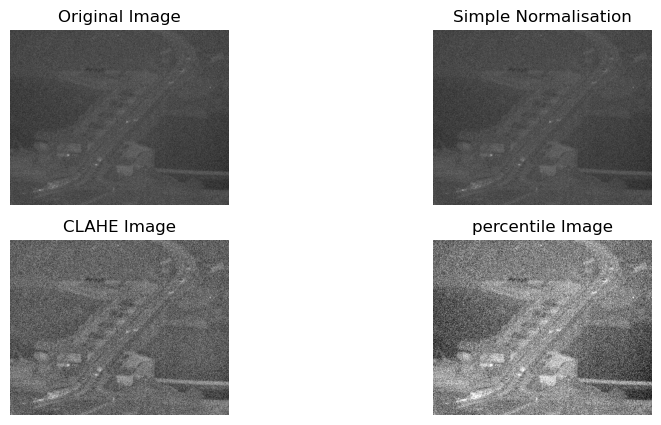

In [6]:
# plot images with both images 
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2, figsize=(10, 5))
axs = axs.flatten()
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(img_final_simple, cmap='gray')
axs[1].set_title('Simple Normalisation')
axs[1].axis('off')
axs[2].imshow(img_final, cmap='gray')
axs[2].set_title('CLAHE Image')
axs[2].axis('off')
axs[3].imshow(img_percentile, cmap='gray')
axs[3].set_title('percentile Image')
axs[3].axis('off')
plt.show()

### comments 
We can see that when we display with .imshow(), it is already normalasing it since the original looks the same as the Simple Normalisation one. 
The CLAHE is a bit better, and the Percentile image is the best one !

#### importation of different defective col

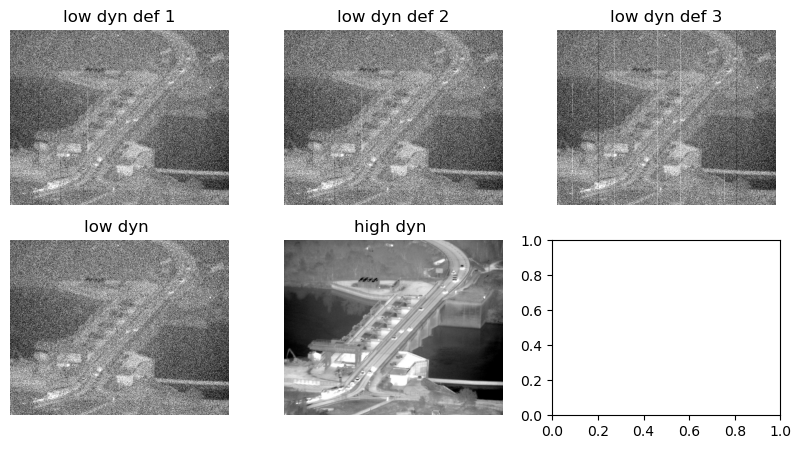

In [7]:
image_def1=convert_to_8_img(io.imread('images/frame_0000ld1.png'))
image_def2=convert_to_8_img(io.imread('images/frame_0000ld2.png'))
image_def3=convert_to_8_img (io.imread('images/frame_0000ld3.png'))
image_ld=convert_to_8_img (io.imread('images/frame_0000ld.png'))
image_hd=convert_to_8_img (io.imread('images/frame_0000.png'))


# plot images with both images 
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
axs = axs.flatten()
axs[0].imshow(image_def2, cmap='gray')
axs[0].set_title('low dyn def 1')
axs[0].axis('off')
axs[1].imshow(image_def2, cmap='gray')
axs[1].set_title('low dyn def 2')
axs[1].axis('off')
axs[2].imshow(image_def3, cmap='gray')
axs[2].set_title('low dyn def 3')
axs[2].axis('off')
axs[3].imshow(image_ld, cmap='gray')
axs[3].set_title('low dyn ')
axs[3].axis('off')
axs[4].imshow(image_hd, cmap='gray')
axs[4].set_title('high dyn ')
axs[4].axis('off')
plt.show()

### test autres images 

/var/folders/ty/mz254c797ml4f8jydylf3h6c0000gn/T/ipykernel_31253/2206673827.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_to_test)


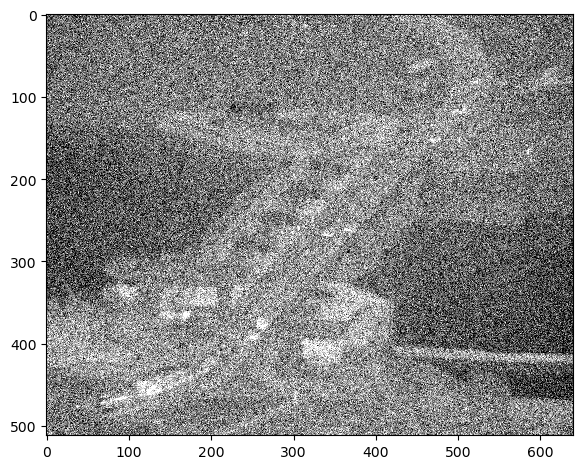

In [8]:
img_to_test=convert_to_8_img(io.imread('images/frame_0001_ld.png'))

io.imshow(img_to_test)

# Defective columns Detection 

### Test de Morphological techniques : Dilatation 

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

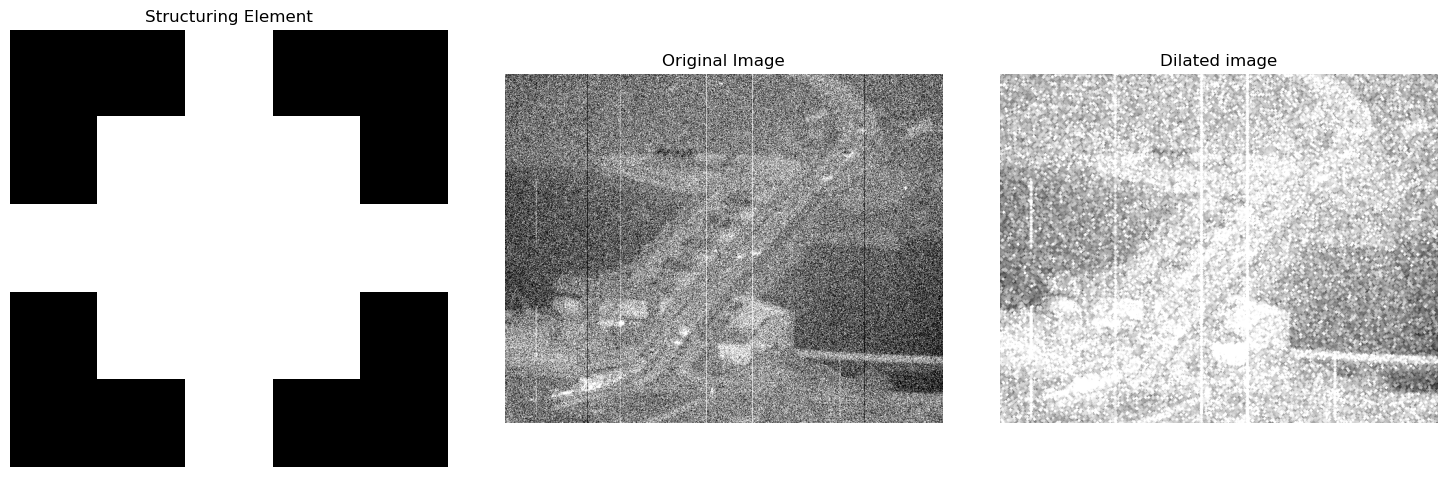

In [19]:
SE1 = morphology.diamond(2)
image_def3_dilated= morphology.dilation(image_def3, SE1)

fig, ax = plt.subplots(1, 3, figsize=(15,5))
fig.tight_layout()
ax[0].imshow(SE1, cmap='gray')
ax[0].set_title('Structuring Element')
ax[0].axis('off')


ax[1].imshow(image_def3, cmap='gray')
ax[1].set_title('Original Image')
ax[1].axis('off')

ax[2].imshow(image_def3_dilated, cmap='gray')
ax[2].set_title('Dilated image')
ax[2].axis('off')

### Test de Morpho techniques : Region Growing 

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

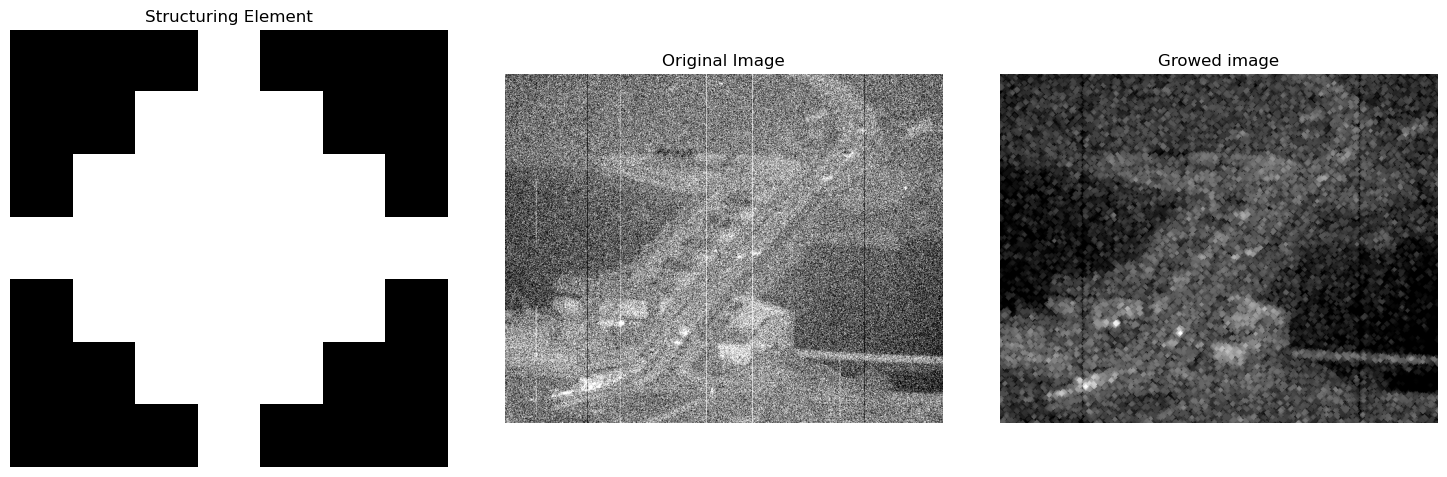

In [18]:
SE2 = morphology.diamond(3)
image_def3_growed= morphology.opening(image_def3, SE2)
# large_circles_2 = morphology.remove_small_holes(img_circle, area_threshold=50)


fig, ax = plt.subplots(1, 3, figsize=(15,5))
fig.tight_layout()
ax[0].imshow(SE2, cmap='gray')
ax[0].set_title('Structuring Element')
ax[0].axis('off')


ax[1].imshow(image_def3, cmap='gray')
ax[1].set_title('Original Image')
ax[1].axis('off')

ax[2].imshow(image_def3_growed, cmap='gray')
ax[2].set_title('Growed image')
ax[2].axis('off')

### Test Morpho : Gradient 

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

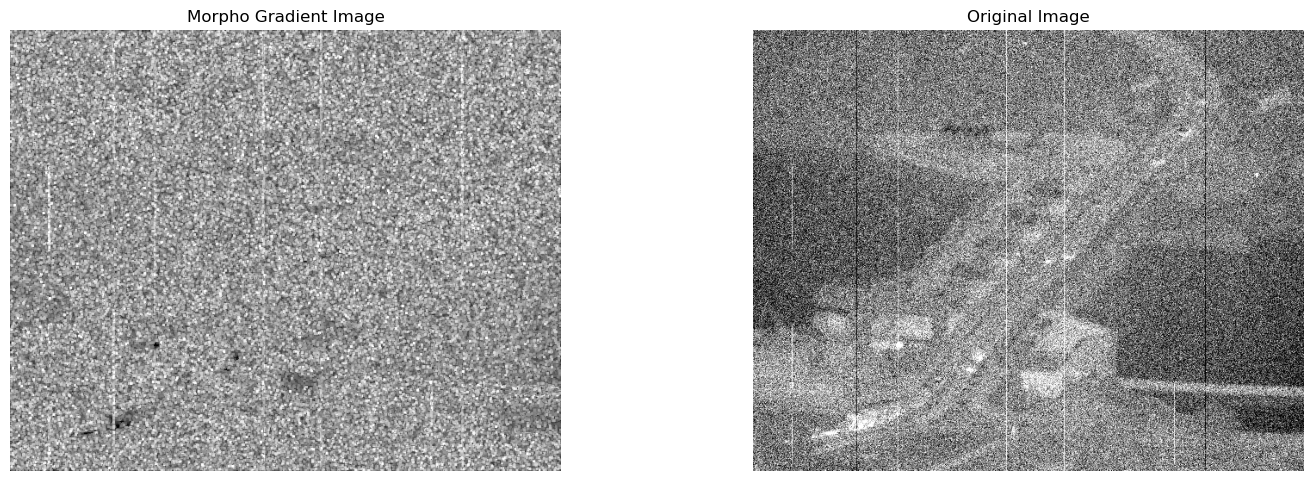

In [ ]:
from scipy import ndimage
image_def3_grad = ndimage.morphological_gradient(image_def3, size=(3,3))

fig, ax = plt.subplots(1, 2, figsize=(15,5))
fig.tight_layout()
ax[0].imshow(image_def3, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow( image_def3_grad, cmap='gray')
ax[1].set_title('Morpho Gradient Image')
ax[1].axis('off')


### Comment 
Bon bah ca marche pas; Flopp

### Test 